In [5]:
from multi_stock_downloader import MultiStockDownloader

import pandas as pd

In [14]:
dl = MultiStockDownloader(
    tickers=['AAPL.O', 'AMZN.O', 'NVDA.O', 'MSFT.O', 'GOOGL.O', 'KO', 'NOC.N', 'PBR.N', 'C', 'BIMBOA.MX'],
    start_date='2023-01-01'
)
data = dl.download()
print(data.head())

Successfully downloaded 797 records
Successfully downloaded 796 records
Successfully downloaded 797 records
Successfully downloaded 796 records
Successfully downloaded 797 records
Successfully downloaded 796 records
Successfully downloaded 797 records
Successfully downloaded 797 records
Successfully downloaded 797 records
Successfully downloaded 799 records
            AAPL.O  AMZN.O  NVDA.O  MSFT.O  GOOGL.O     KO   NOC.N  PBR.N  \
Date                                                                        
2023-01-02    <NA>    <NA>    <NA>    <NA>     <NA>   <NA>    <NA>   <NA>   
2023-01-03  125.07   85.82  14.315  239.58    89.12  62.95  540.33    9.5   
2023-01-04  126.36   85.14  14.749   229.1    88.08  62.92  526.45   9.71   
2023-01-05  125.02   83.12  14.265  222.31     86.2   62.2  528.52  10.13   
2023-01-06  129.62   86.08  14.859  224.93    87.34   63.4  521.42  10.28   

                C  BIMBOA.MX  
Date                          
2023-01-02   <NA>      84.72  
2023-01

In [15]:
data

,AAPL.O,AMZN.O,NVDA.O,MSFT.O,GOOGL.O,KO,NOC.N,PBR.N,C,BIMBOA.MX
Date,,,,,,,,,,
2023-01-02,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,84.72
2023-01-03,125.07,85.82,14.315,239.58,89.12,62.95,540.33,9.5,45.78,84.89
2023-01-04,126.36,85.14,14.749,229.1,88.08,62.92,526.45,9.71,46.96,85.39
2023-01-05,125.02,83.12,14.265,222.31,86.2,62.2,528.52,10.13,46.75,87.73
2023-01-06,129.62,86.08,14.859,224.93,87.34,63.4,521.42,10.28,47.31,88.41
...,...,...,...,...,...,...,...,...,...,...
2026-03-03,263.75,208.73,180.05,403.93,303.58,79.34,759.11,16.96,110.76,61.15
2026-03-04,262.52,216.82,183.04,405.2,303.13,78.1,753.84,16.77,111.32,64.51
2026-03-05,260.29,218.94,183.34,410.68,300.88,77.03,740.01,16.73,108.95,62.89


In [16]:
def get_prices_by_date(data: pd.DataFrame, date: str) -> pd.Series:
    """
    Extrae los precios de cierre de todos los tickers para una fecha específica.
    Args:
        data: DataFrame con fechas como índice y tickers como columnas.
        date: Fecha en formato 'YYYY-MM-DD'.
    Returns:
        pd.Series con los precios de cierre de cada ticker en esa fecha.
    Raises:
        KeyError: Si la fecha no existe en el DataFrame.
        ValueError: Si el formato de la fecha es inválido.
    """
    try:
        return data.loc[date]
    except KeyError:
        fechas_disponibles = data.index.strftime('%Y-%m-%d').tolist()
        raise KeyError(
            f"La fecha '{date}' no se encontró en el DataFrame.\n"
            f"Rango disponible: {fechas_disponibles[0]} → {fechas_disponibles[-1]}"
        )

In [17]:
precios = get_prices_by_date(data, '2023-01-03')
precios

AAPL.O       125.07
AMZN.O        85.82
NVDA.O       14.315
MSFT.O       239.58
GOOGL.O       89.12
KO            62.95
NOC.N        540.33
PBR.N           9.5
C             45.78
BIMBOA.MX     84.89
Name: 2023-01-03 00:00:00, dtype: Float64

In [18]:
type(precios)

pandas.core.series.Series

In [28]:
import json
import pandas as pd
def portfolio_to_dataframe(json_path: str, date: str) -> pd.DataFrame:
    """
    Lee portfolio.json y devuelve un DataFrame de un solo renglón
    con la fecha especificada como índice y el monto de inversión por RIC.
    Args:
        json_path: Ruta al archivo JSON (ej. 'portfolio.json').
        date:      Fecha en formato 'YYYY-MM-DD'.
    Returns:
        pd.DataFrame de una fila con índice = date y columnas = RICs.
    """
    with open(json_path, "r") as f:
        portfolio = json.load(f)["portfolio"]
    return pd.DataFrame(portfolio, index=pd.DatetimeIndex([date], name="Date"))

In [29]:
portfolio_df = portfolio_to_dataframe("portfolio.json", "2023-01-03")
print(portfolio_df)


            AAPL.O  AMZN.O  NVDA.O  MSFT.O  GOOGL.O      KO   NOC.N   PBR.N  \
Date                                                                          
2023-01-03  100000  100000  100000  100000   100000  100000  100000  100000   

                 C  BIMBOA.MX  
Date                           
2023-01-03  100000     100000  


In [30]:
portfolio_df

,AAPL.O,AMZN.O,NVDA.O,MSFT.O,GOOGL.O,KO,NOC.N,PBR.N,C,BIMBOA.MX
Date,,,,,,,,,,
2023-01-03,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000


In [25]:
portfolio_df.iloc[1]

AAPL.O       100000
AMZN.O       100000
NVDA.O       100000
MSFT.O       100000
GOOGL.O      100000
KO           100000
NOC.N        100000
PBR.N        100000
C            100000
BIMBOA.MX    100000
Name: 2023-01-03 00:00:00, dtype: int64

In [26]:
data.iloc[1]

AAPL.O       125.07
AMZN.O        85.82
NVDA.O       14.315
MSFT.O       239.58
GOOGL.O       89.12
KO            62.95
NOC.N        540.33
PBR.N           9.5
C             45.78
BIMBOA.MX     84.89
Name: 2023-01-03 00:00:00, dtype: Float64

In [27]:
portfolio_df.iloc[1]/data.iloc[1]

AAPL.O         799.552251
AMZN.O         1165.22955
NVDA.O        6985.679357
MSFT.O         417.397112
GOOGL.O       1122.082585
KO            1588.562351
NOC.N          185.072086
PBR.N        10526.315789
C             2184.359983
BIMBOA.MX     1177.995052
Name: 2023-01-03 00:00:00, dtype: Float64

In [31]:

def compute_shares(data: pd.DataFrame, portfolio_df: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula el número de acciones (enteras) que se pueden comprar
    con el monto asignado en portfolio_df, al precio de la fecha
    especificada en su índice.
    Args:
        data:         DataFrame de precios (índice = fechas, columnas = RICs).
        portfolio_df: DataFrame de una fila (fecha + montos por RIC).
    Returns:
        pd.DataFrame de una fila con el número de acciones por RIC.
    """
    date = portfolio_df.index[0]
    precios = data.loc[date, portfolio_df.columns]   # Serie: precio de cada RIC en esa fecha
    shares = (portfolio_df.loc[date] // precios).astype(int)
    return pd.DataFrame(shares).T.set_index(portfolio_df.index)

In [32]:
portfolio_df = portfolio_to_dataframe("portfolio.json", "2023-01-03")
shares_df    = compute_shares(data, portfolio_df)
print(shares_df)

            AAPL.O  AMZN.O  NVDA.O  MSFT.O  GOOGL.O    KO  NOC.N  PBR.N     C  \
Date                                                                            
2023-01-03     799    1165    6985     417     1122  1588    185  10526  2184   

            BIMBOA.MX  
Date                   
2023-01-03       1177  


In [33]:
def compute_portfolio_value(data: pd.DataFrame, shares_df: pd.DataFrame) -> pd.DataFrame:
    """
    Genera un DataFrame con precios, número de shares (constante) y el
    valor del portafolio (precio × shares) para cada fecha posterior
    a la fecha de compra.
    Args:
        data:      DataFrame de precios (índice = fechas, columnas = RICs).
        shares_df: DataFrame de una fila con el número de shares por RIC.
    Returns:
        pd.DataFrame con MultiIndex en columnas:
            - 'price':          precio de cierre por RIC
            - 'shares':         número de acciones (constante)
            - 'value':          precio × shares por RIC
            - 'portfolio_value': valor total del portafolio (suma de todos los RICs)
    """
    start_date = shares_df.index[0]
    rics       = shares_df.columns.tolist()
    # Filtrar datos desde la fecha de compra
    prices = data.loc[start_date:, rics].copy()
    # Construir MultiIndex en columnas: (métrica, RIC)
    price_df  = prices.copy()
    shares_   = pd.DataFrame(
        {ric: shares_df.loc[start_date, ric] for ric in rics},
        index=prices.index
    )
    value_df  = price_df * shares_
    price_df.columns  = pd.MultiIndex.from_product([["price"],  rics])
    shares_.columns   = pd.MultiIndex.from_product([["shares"], rics])
    value_df.columns  = pd.MultiIndex.from_product([["value"],  rics])
    result = pd.concat([price_df, shares_, value_df], axis=1)
    # Valor total del portafolio (suma de todos los RICs)
    result[("portfolio_value", "total")] = value_df.sum(axis=1)
    return result

In [34]:
portfolio_df = portfolio_to_dataframe("portfolio.json", "2023-01-03")
shares_df    = compute_shares(data, portfolio_df)
pv           = compute_portfolio_value(data, shares_df)
print(pv.head())
print(pv[("portfolio_value", "total")])

             price                                                       \
            AAPL.O AMZN.O  NVDA.O  MSFT.O GOOGL.O     KO   NOC.N  PBR.N   
Date                                                                      
2023-01-03  125.07  85.82  14.315  239.58   89.12  62.95  540.33    9.5   
2023-01-04  126.36  85.14  14.749   229.1   88.08  62.92  526.45   9.71   
2023-01-05  125.02  83.12  14.265  222.31    86.2   62.2  528.52  10.13   
2023-01-06  129.62  86.08  14.859  224.93   87.34   63.4  521.42  10.28   
2023-01-09  130.15  87.36  15.628  227.12   88.02  62.61  495.41  10.24   

                             ...     value                                  \
                C BIMBOA.MX  ...    AMZN.O      NVDA.O    MSFT.O   GOOGL.O   
Date                         ...                                             
2023-01-03  45.78     84.89  ...   99980.3   99990.275  99904.86  99992.64   
2023-01-04  46.96     85.39  ...   99188.1  103021.765   95534.7  98825.76   
2023-01-0

In [35]:
pv 

price                                                        \
            AAPL.O  AMZN.O  NVDA.O  MSFT.O GOOGL.O     KO   NOC.N  PBR.N   
Date                                                                       
2023-01-03  125.07   85.82  14.315  239.58   89.12  62.95  540.33    9.5   
2023-01-04  126.36   85.14  14.749   229.1   88.08  62.92  526.45   9.71   
2023-01-05  125.02   83.12  14.265  222.31    86.2   62.2  528.52  10.13   
2023-01-06  129.62   86.08  14.859  224.93   87.34   63.4  521.42  10.28   
2023-01-09  130.15   87.36  15.628  227.12   88.02  62.61  495.41  10.24   
...            ...     ...     ...     ...     ...    ...     ...    ...   
2026-03-03  263.75  208.73  180.05  403.93  303.58  79.34  759.11  16.96   
2026-03-04  262.52  216.82  183.04   405.2  303.13   78.1  753.84  16.77   
2026-03-05  260.29  218.94  183.34  410.68  300.88  77.03  740.01  16.73   
2026-03-06  257.46  213.21  177.82  408.96  298.52  77.04  756.13   17.6   
2026-03-09  259.88    <NA>  182.65    <NA>  306.36   <NA>  747.34  18.16   

                              ...      value                         \
                 C BIMBOA.MX  ...     AMZN.O      NVDA.O     MSFT.O   
Date                          ...                                     
2023-01-03   45.78     84.89  ...    99980.3   99990.275   99904.86   
2023-01-04   46.96     85.39  ...    99188.1  103021.765    95534.7   
2023-01-05   46.75     87.73  ...    96834.8   99641.025   92703.27   
2023-01-06   47.31     88.41  ...   100283.2  103790.115   93795.81   
2023-01-09   47.54      90.3  ...   101774.4   109161.58   94709.04   
...            ...       ...  ...        ...         ...        ...   
2026-03-03  110.76     61.15  ...  243170.45  1257649.25  168438.81   
2026-03-04  111.32     64.51  ...   252595.3   1278534.4   168968.4   
2026-03-05  108.95     62.89  ...   255065.1   1280629.9  171253.56   
2026-03-06  106.53     61.23  ...  248389.65   1242072.7  170536.32   
2026-03-09  106.59      61.3  ...       <NA>  1275810.25       <NA>   

                                                                              \
              GOOGL.O         KO      NOC.N      PBR.N          C  BIMBOA.MX   
Date                                                                           
2023-01-03   99992.64    99964.6   99961.05    99997.0   99983.52   99915.53   
2023-01-04   98825.76   99916.96   97393.25  102207.46  102560.64  100504.03   
2023-01-05    96716.4    98773.6    97776.2  106628.38   102102.0  103258.21   
2023-01-06   97995.48   100679.2    96462.7  108207.28  103325.04  104058.57   
2023-01-09   98758.44   99424.68   91650.85  107786.24  103827.36   106283.1   
...               ...        ...        ...        ...        ...        ...   
2026-03-03  340616.76  125991.92  140435.35  178520.96  241899.84   71973.55   
2026-03-04  340111.86   124022.8   139460.4  176521.02  243122.88   75928.27   
2026-03-05  337587.36  122323.64  136901.85  176099.98   237946.8   74021.53   
2026-03-06  334939.44  122339.52  139884.05   185257.6  232661.52   72067.71   
2026-03-09  343735.92       <NA>   138257.9  191152.16  232792.56    72150.1   

           portfolio_value  
                     total  
Date                        
2023-01-03      999620.705  
2023-01-04     1000114.305  
2023-01-05      994324.865  
2023-01-06     1012163.775  
2023-01-09      1017365.54  
...                    ...  
2026-03-03      2979433.14  
2026-03-04      3009018.81  
2026-03-05      2999801.43  
2026-03-06      2953859.05  
2026-03-09      2461543.01  

[821 rows x 31 columns]

<Axes: title={'center': 'Evolución del Portafolio'}, xlabel='Date'>

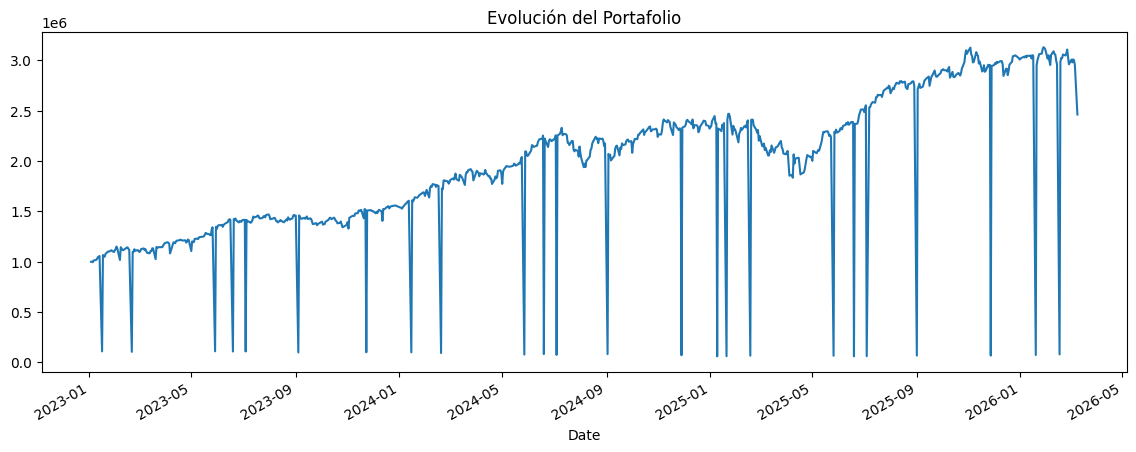

In [36]:
pv[("portfolio_value", "total")].plot(title="Evolución del Portafolio", figsize=(14, 5))